In [1]:
import glob
import os
import librosa
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
import tensorflow as tf
from tensorflow.keras import layers, models

# Path to the metadata file
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'

# Dictionary to hold file identifiers and labels
labels = {}

# Open and read the metadata file
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]  # Example: DF_E_2000011
        label = parts[5]            # Example: "spoof"
        labels[file_identifier] = label

# Directory containing the undersampled audio files
undersampled_audio_dir = r'D:\audio_files\undersampled_audio_10_percent'

# Find all .flac files in the undersampled directory
audio_files = glob.glob(os.path.join(undersampled_audio_dir, '*.flac'))

# Create a list to store only those files that have corresponding labels in the metadata
valid_audio_files = []
valid_labels = []

# Loop through the audio files and match with metadata labels
for audio_file in audio_files:
    file_name = os.path.basename(audio_file)
    file_identifier = file_name.split('.')[0]  # Extract the file identifier (before the extension)

    # Check if the file identifier exists in the metadata labels
    if file_identifier in labels:
        valid_audio_files.append(audio_file)  # Keep this audio file
        valid_labels.append(labels[file_identifier])  # Store the corresponding label (spoof/bonafide)

# Print the number of matching files
print(f"Found {len(valid_audio_files)} audio files with corresponding labels.")

# Audio to MFCC conversion function
def audio_to_mfcc(audio_file, sr=22050, n_mfcc=13):
    """Convert audio to MFCC."""
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

# Resize the MFCC to a fixed size function
def resize_spectrogram(spectrogram, target_size=(200, 200)):
    """Resize the MFCC to a fixed size."""
    return cv2.resize(spectrogram, target_size)

# Preprocessing the audio files
def preprocess_audio_files(audio_files, labels, target_size=(200, 200)):
    """Convert audio files to MFCCs, resize, and normalize them."""
    mfcc_data = []
    label_data = []

    for audio_file, label in zip(audio_files, labels):
        mfcc = audio_to_mfcc(audio_file)
        resized_mfcc = resize_spectrogram(mfcc, target_size)
        
        # Safe normalization: Check if the max value is 0
        max_value = np.max(resized_mfcc)
        if max_value > 0:
            normalized_mfcc = resized_mfcc / max_value
        else:
            normalized_mfcc = resized_mfcc  # Leave it as is if the max is 0

        mfcc_data.append(normalized_mfcc)
        label_data.append(1 if label == 'spoof' else 0)  # Binary label (1: spoof, 0: bonafide)

    return np.array(mfcc_data), np.array(label_data)

# Preprocess the valid audio files and labels
X, y = preprocess_audio_files(valid_audio_files, valid_labels, target_size=(200, 200
                                                                            ))

# Add a channel dimension for CNN
X = np.expand_dims(X, axis=-1)

# Stratified 70:30 train-test split
def stratified_split_70_30(X, y, test_size=0.2, random_state=42):
    """Split dataset into stratified 70/30 sets."""
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    
    for train_idx, test_idx in strat_split.split(X, y):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
    
    # Ensure that the training set has balanced classes
    class_counts = np.bincount(y_train)
    min_class_count = min(class_counts)
    spoof_indices = np.where(y_train == 1)[0][:min_class_count]
    bonafide_indices = np.where(y_train == 0)[0][:min_class_count]
    balanced_train_indices = np.concatenate([spoof_indices, bonafide_indices])
    X_train_balanced, y_train_balanced = X_train[balanced_train_indices], y_train[balanced_train_indices]

    return X_train_balanced, X_test, y_train_balanced, y_test

# Perform the stratified 80/30 split
X_train, X_test, y_train, y_test = stratified_split_70_30(X, y, test_size=0.2, random_state=42)

# Print the distribution of classes to verify stratification
print(f"Training set distribution: {np.bincount(y_train)}")
print(f"Test set distribution: {np.bincount(y_test)}")

Found 4522 audio files with corresponding labels.
Training set distribution: [1808 1808]
Test set distribution: [453 452]


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 156816)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │    10,036,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,036,801 (38.29 MB)

 Trainable params: 10,036,801 (38.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 818ms/step - accuracy: 0.6224 - loss: 1.2722 - val_accuracy: 0.7436 - val_loss: 0.8922
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 562ms/step - accuracy: 0.6558 - loss: 0.9513 - val_accuracy: 0.7425 - val_loss: 0.7941
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 516ms/step - accuracy: 0.6405 - loss: 0.7853 - val_accuracy: 0.7514 - val_loss: 0.7456
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 538ms/step - accuracy: 0.5787 - loss: 0.8095 - val_accuracy: 0.7204 - val_loss: 0.7310
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 515ms/step - accuracy: 0.6828 - loss: 0.7385 - val_accuracy: 0.7503 - val_loss: 0.7075
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 499ms/step - accuracy: 0.7123 - loss: 0.6981 - val_accuracy: 0.7536 - val_loss: 0.6654
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 507ms/step - accuracy: 0.6618 - loss: 0.7044 - val_accuracy: 0.7492 - val_loss: 0.6497
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 513ms/step - accuracy: 0.7296 - loss: 0.6542 - val_accuracy: 0.7470 - v

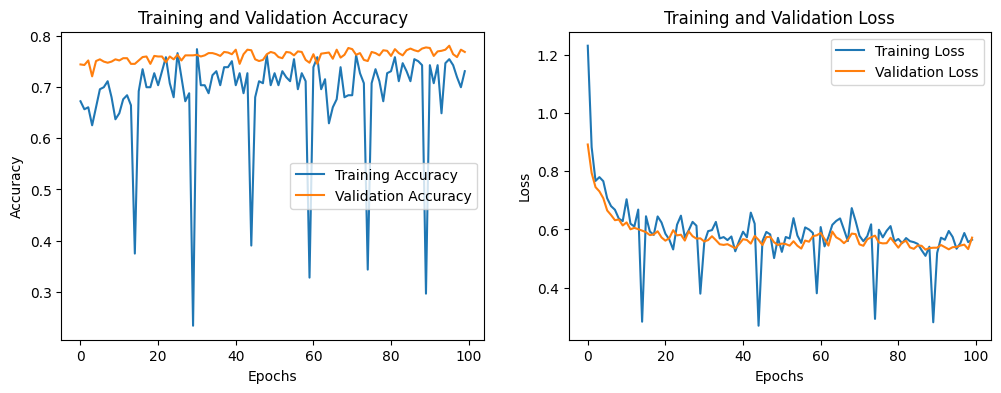

In [8]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Convert numpy arrays to TensorFlow tensors
X_train_tensor = tf.convert_to_tensor(X_train, dtype=tf.float32)
X_test_tensor = tf.convert_to_tensor(X_test, dtype=tf.float32)

# Convert single-channel grayscale data to 3-channel RGB data
X_train_rgb = tf.image.grayscale_to_rgb(X_train_tensor)  # Shape will be (batch_size, 200, 200, 3)
X_test_rgb = tf.image.grayscale_to_rgb(X_test_tensor)    # Shape will be (batch_size, 200, 200, 3)

# Define the CNN model with modified parameters to fit the given specifications
def create_cnn_model(input_shape):
    model = tf.keras.Sequential()

    # First Conv layer with 16 filters
    model.add(tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))  # Output shape will be approximately (100, 100, 16)
    
    # Flatten and add fully connected layers with dropout
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.Dropout(0.6))  # Dropout for regularization

    # Output layer
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    return model

# Set the input shape as (200, 200, 3) for RGB data
input_shape = (200, 200, 3)

# Create the model with the specified input shape
model = create_cnn_model(input_shape)

# Compile the model with a custom learning rate
learning_rate = 0.001
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Train the model using the RGB data
history = model.fit(
    X_train_rgb, y_train, 
    epochs=100,               # Specified in the table
    steps_per_epoch=8,       # Specified in the table
    batch_size=32, 
    validation_data=(X_test_rgb, y_test)
)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_rgb, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 198, 198, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 99, 99, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 97, 97, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 46, 46, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 16928)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │     1,083,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089,553 (4.16 MB)

 Trainable params: 1,089,553 (4.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - accuracy: 0.6627 - loss: 0.6999 - val_accuracy: 0.7580 - val_loss: 0.5805
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step - accuracy: 0.7714 - loss: 0.5646 - val_accuracy: 0.7591 - val_loss: 0.5784
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - accuracy: 0.7691 - loss: 0.5661 - val_accuracy: 0.7591 - val_loss: 0.5669
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 114ms/step - accuracy: 0.7772 - loss: 0.5452 - val_accuracy: 0.7602 - val_loss: 0.5677
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 113ms/step - accuracy: 0.7773 - loss: 0.5546 - val_accuracy: 0.7713 - val_loss: 0.5517
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step - accuracy: 0.7720 - loss: 0.5433 - val_accuracy: 0.7635 - val_loss: 0.5625
Epoch 7/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step - accuracy: 0.7821 - loss: 0.5353 - val_accuracy: 0.7691 - val_loss: 0.5551
Epoch 8/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 114ms/step - accuracy: 0.7896 -

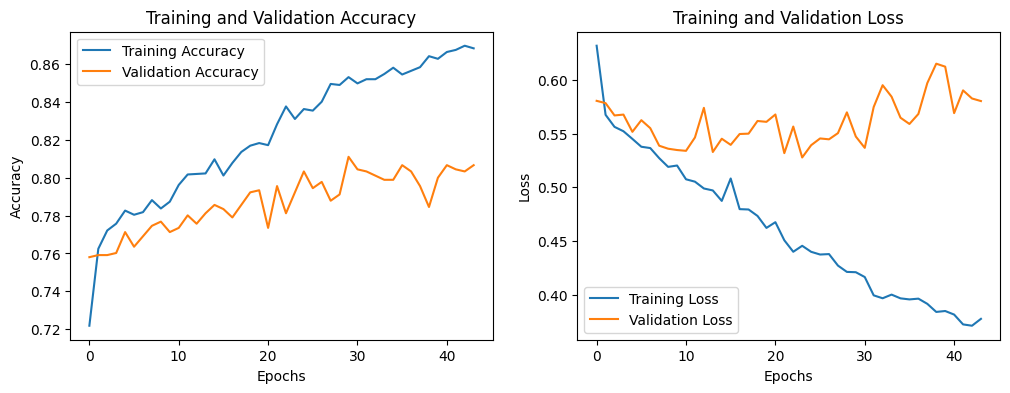

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Convert X_train and X_test to 3-channel RGB by duplicating the single channel
X_train_rgb = np.repeat(X_train, 3, axis=-1)  # Shape will be (num_samples, 200, 200, 3)
X_test_rgb = np.repeat(X_test, 3, axis=-1)    # Shape will be (num_samples, 200, 200, 3)

# Convert to TensorFlow tensors
X_train_rgb = tf.convert_to_tensor(X_train_rgb, dtype=tf.float32)
X_test_rgb = tf.convert_to_tensor(X_test_rgb, dtype=tf.float32)

# Define the CNN model with adjusted parameters to reduce overfitting
def create_cnn_model(input_shape):
    model = tf.keras.Sequential()

    # First Conv layer with fewer filters
    model.add(tf.keras.layers.Conv2D(8, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))
    
    # Second Conv layer with fewer filters
    model.add(tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))
    
    # Third Conv layer with fewer filters
    model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))
    
    # Flatten and add fully connected layers with increased dropout
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.Dropout(0.7))  # Increased dropout to reduce overfitting

    # Output layer
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    return model

# Create the model with the modified parameters
input_shape = (200, 200, 3)  # Shape of input (height, width, channels)
model = create_cnn_model(input_shape)

# Set a custom learning rate
learning_rate = 0.001
optimizer = Adam(learning_rate=learning_rate)

# Compile the model with the custom learning rate
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Set up early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=0, restore_best_weights=True)

# Train the model with early stopping, using the RGB data
history = model.fit(X_train_rgb, y_train, epochs=100, batch_size=32, validation_data=(X_test_rgb, y_test), callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_rgb, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 198, 198, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 99, 99, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 97, 97, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 46, 46, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 16928)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │     1,083,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089,553 (4.16 MB)

 Trainable params: 1,089,553 (4.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - accuracy: 0.5747 - loss: 0.7575 - val_accuracy: 0.7536 - val_loss: 0.5827
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 114ms/step - accuracy: 0.6544 - loss: 0.6549 - val_accuracy: 0.7580 - val_loss: 0.5646
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - accuracy: 0.6365 - loss: 0.6276 - val_accuracy: 0.7580 - val_loss: 0.5900
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - accuracy: 0.6595 - loss: 0.6337 - val_accuracy: 0.7669 - val_loss: 0.5812
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - accuracy: 0.6665 - loss: 0.6072 - val_accuracy: 0.7613 - val_loss: 0.5870
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - accuracy: 0.6779 - loss: 0.6086 - val_accuracy: 0.7558 - val_loss: 0.5647
Epoch 7/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - accuracy: 0.7045 - loss: 0.5997 - val_accuracy: 0.7492 - val_loss: 0.5738
Epoch 8/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - accuracy: 0.6889 -

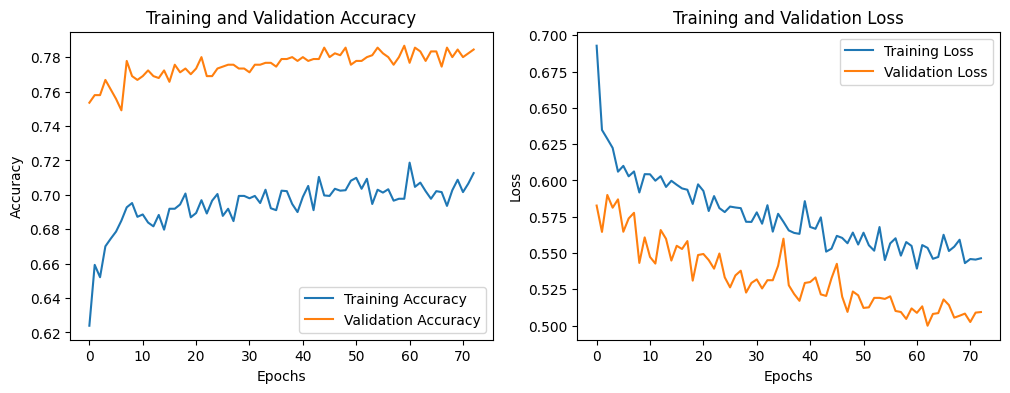

In [17]:
# Convert X_train and X_test to 3-channel RGB by duplicating the single channel
X_train_rgb = np.repeat(X_train, 3, axis=-1)  # Shape will be (num_samples, 200, 200, 3)
X_test_rgb = np.repeat(X_test, 3, axis=-1)    # Shape will be (num_samples, 200, 200, 3)

# Convert to TensorFlow tensors
X_train_rgb = tf.convert_to_tensor(X_train_rgb, dtype=tf.float32)
X_test_rgb = tf.convert_to_tensor(X_test_rgb, dtype=tf.float32)

# Define the CNN model with adjusted parameters to reduce overfitting
def create_cnn_model(input_shape):
    model = tf.keras.Sequential()

    # First Conv layer with fewer filters
    model.add(tf.keras.layers.Conv2D(8, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))
    
    # Second Conv layer with fewer filters
    model.add(tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))
    
    # Third Conv layer with fewer filters
    model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))
    
    # Flatten and add fully connected layers with increased dropout
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.Dropout(0.9))  # Increased dropout to reduce overfitting

    # Output layer
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    return model

# Create the model with the modified parameters
input_shape = (200, 200, 3)  # Shape of input (height, width, channels)
model = create_cnn_model(input_shape)

# Set a custom learning rate
learning_rate = 0.001
optimizer = Adam(learning_rate=learning_rate)

# Compile the model with the custom learning rate
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Set up early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model with early stopping, using the RGB data
history = model.fit(X_train_rgb, y_train, epochs=100, batch_size=32, validation_data=(X_test_rgb, y_test), callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_rgb, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()